<a href="https://colab.research.google.com/github/Hajer5503/Esprit-PI-4DS5-AgriSmart/blob/feature%2Firrigation-rl/modules/irrigation_rl/notebooks/RLlayer1_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Irrigation Optimization – Layer 1: Predictive Forecasting

## Business Objective

Optimize irrigation scheduling to:
- **Maintain optimal soil moisture levels**
- **Reduce water waste by 20–40%**
- **Prevent crop stress**
- **Improve sustainability**

---

## Data Science Objective

Develop a **supervised forecasting model** that predicts:

1. **Next-day root-zone soil moisture** (`sm_root` at `t+1`)
2. **Next-day crop water requirement** (`ETc` at `t+1`)

These predictions feed directly into the irrigation scheduling system, telling the controller how much water the crop will need tomorrow.

---

## Why Layer 1 before Layer 2?

```
Layer 1 (This notebook)          Layer 2 (RL Agent)
─────────────────────────        ─────────────────────────────────
Input: weather + soil state  →   Input: Layer 1 predictions
Output: sm_root(t+1), ETc(t+1)   Output: irrigation action (mm/day)
Model: LSTM / XGBoost            Model: DQN agent
```

Layer 1 acts as a **digital twin** of the soil–weather system.
Layer 2 uses its forecasts to plan ahead.

---

## Problem Type

| Target | Type | Metric |
|--------|------|--------|
| `sm_root(t+1)` | Regression / Time-series forecasting | R² ≥ 0.90, RMSE minimised |
| `etc_mm(t+1)` | Regression / Time-series forecasting | R² ≥ 0.90, RMSE minimised |

---

## MDP Connection

The predictions from Layer 1 correspond directly to MDP state variables:

| MDP State Variable | Layer 1 Output |
|-------------------|----------------|
| `soil_moisture_9_27` (sm_shallow) | Predicted by model |
| `soil_moisture_27_81` (sm_deep) | Predicted by model |
| `ET₀` | Predicted by model |

---

## Next Steps

1. `02_data_preparation.ipynb` — Feature engineering & dataset construction
2. `03_model_training.ipynb` — XGBoost + LSTM training & evaluation

## Libraries Importation

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.gridspec as gridspec
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

np.random.seed(42)
print("✅ Libraries loaded")

✅ Libraries loaded


## Dataset Preview

In [20]:
df = pd.read_csv('rl_dataset_final.csv', sep=';',
                 parse_dates=['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nColumns:")
for c in df.columns:
    print(f"  {c:<22}  min={df[c].min() if c!='date' else 'N/A':>10}  "
          f"max={df[c].max() if c!='date' else 'N/A':>10}  "
          f"mean={df[c].mean() if c!='date' else 'N/A':>10}" if c!='date' else f"  {c}")

df.head()

Shape      : (772, 15)
Date range : 2022-11-16 → 2026-02-13

Columns:
  date
  day_of_season           min=         1  max=       228  mean=107.91062176165804
  precip_mm               min=       0.0  max=      31.7  mean=0.8259067357512954
  et0_mm                  min=      0.37  max=      8.67  mean=3.286217616580311
  temp_c                  min=     6.675  max=   30.5125  mean=16.631722258203798
  rh_pct                  min=      26.5  max=    93.875  mean=62.77250647668394
  wind_kmh                min=       2.5  max=24.620833333333334  mean=8.563420228842833
  kc                      min=      0.35  max=      1.15  mean=0.7972668393782384
  etc_mm                  min=      0.42  max=    5.7535  mean=2.211109455958549
  sm_shallow              min=0.1377916666666666  max=0.3424166666666666  mean=0.18820790155440412
  sm_deep                 min=  0.167875  max=    0.2725  mean=0.21259833765112257
  sm_root                 min=    0.1511  max=    0.3037  mean=0.1979624352331606

,date,day_of_season,precip_mm,et0_mm,temp_c,rh_pct,wind_kmh,kc,etc_mm,sm_shallow,sm_deep,sm_root,irrigation_mm,net_balance_mm,delta_sm
0,2022-11-16,16,0.3,2.53,21.818750,39.500000,4.556250,0.7,1.771,0.178750,0.230000,0.1992,1.8165,0.3455,-0.0008
1,2022-11-17,17,0.0,2.23,20.404167,56.666667,5.979167,0.7,1.561,0.178000,0.229083,0.1984,1.6073,0.0463,-0.0011
2,2022-11-18,18,0.0,3.23,20.700000,54.541667,8.512500,0.7,2.261,0.176875,0.228000,0.1973,2.3084,0.0474,-0.0005
3,2022-11-19,19,0.0,3.24,18.962500,52.125000,10.700000,0.7,2.268,0.176333,0.227458,0.1968,2.3159,0.0479,-0.0004
4,2022-11-20,20,1.4,3.01,14.800000,55.958333,16.637500,0.7,2.107,0.176000,0.227042,0.1964,2.1553,1.4483,0.0000


## Targets to Predict

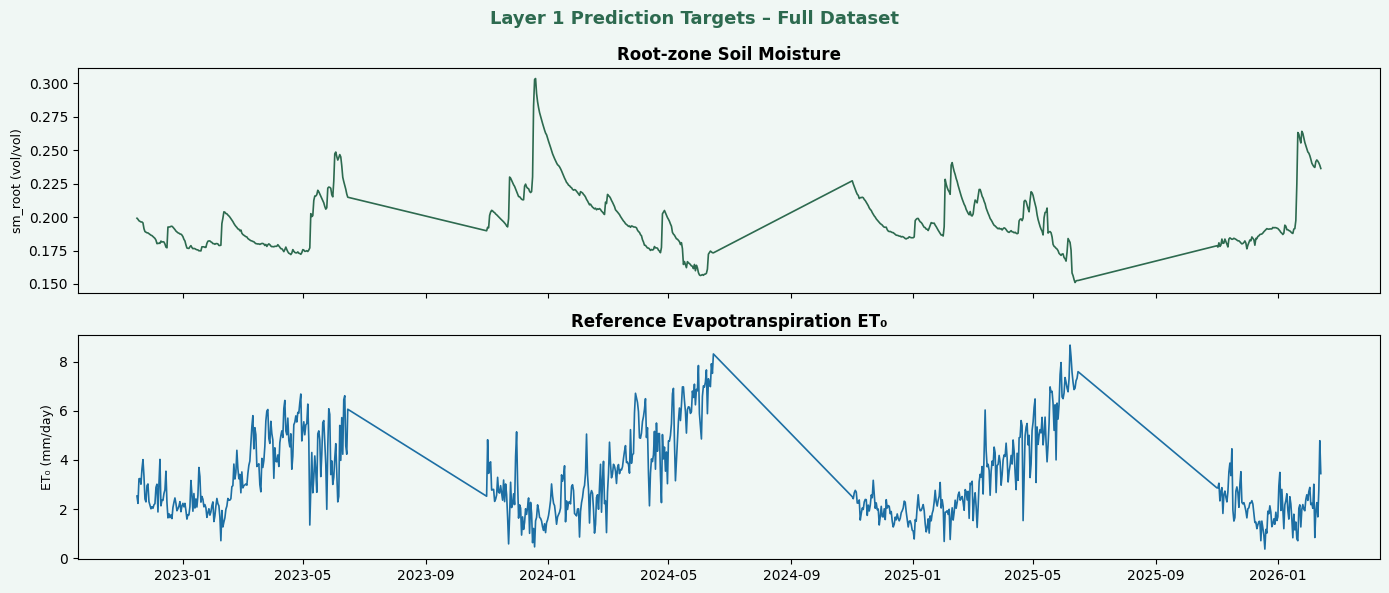

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, facecolor='#f0f7f4')
fig.suptitle('Layer 1 Prediction Targets – Full Dataset', fontsize=13,
             fontweight='bold', color='#2d6a4f')

axes[0].plot(df['date'], df['sm_root'], color='#2d6a4f', lw=1.2)
axes[0].set_ylabel('sm_root (vol/vol)', fontsize=9)
axes[0].set_title('Root-zone Soil Moisture', fontweight='bold')
axes[0].set_facecolor('#f0f7f4')

axes[1].plot(df['date'], df['et0_mm'], color='#1d6fa4', lw=1.2)
axes[1].set_ylabel('ET₀ (mm/day)', fontsize=9)
axes[1].set_title('Reference Evapotranspiration ET₀', fontweight='bold')
axes[1].set_facecolor('#f0f7f4')

plt.tight_layout()
plt.savefig('targets_overview.png', dpi=130, bbox_inches='tight')
plt.show()

## Feature Engineering & Dataset Construction

**Objective:** Transform the raw ERA5/FAO-56 dataset into a supervised learning dataset ready for XGBoost and LSTM.

| Step | Description |
|------|-------------|
| 1 | Load & validate dataset |
| 2 | Build prediction targets (`sm_root(t+1)`, `etc_mm(t+1)`) |
| 3 | Engineer lag features (t-1, t-3, t-7) |
| 4 | Add rolling statistics (7-day window) |
| 5 | Add calendar & seasonal encodings |
| 6 | Train / validation / test split (chronological) |
| 7 | Scale features |
| 8 | Build LSTM sequences |


### Build Prediction Targets
We shift each target by -1 so that for each row at time `t`, the label is the value at `t+1`.


In [22]:
# Prediction targets: next-day values
# ET₀ predicted directly → ETc reconstructed as ET₀ × Kc (FAO-56 physical relation)
df['target_sm_root'] = df['sm_root'].shift(-1)
df['target_et0_mm']  = df['et0_mm'].shift(-1)

# Drop last row (no t+1 available)
df.dropna(subset=['target_sm_root', 'target_et0_mm'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset after target creation: {len(df)} rows")
print(f"\ntarget_sm_root → min={df['target_sm_root'].min():.4f}  "
      f"max={df['target_sm_root'].max():.4f}  mean={df['target_sm_root'].mean():.4f}")
print(f"target_et0_mm  → min={df['target_et0_mm'].min():.4f}  "
      f"max={df['target_et0_mm'].max():.4f}  mean={df['target_et0_mm'].mean():.4f}")

Dataset after target creation: 771 rows

target_sm_root → min=0.1511  max=0.3037  mean=0.1980
target_et0_mm  → min=0.3700  max=8.6700  mean=3.2872


### Feature Engineering

#### Lag Features

Capture temporal dependency by including past values at `t-1`, `t-3`, `t-7`.

In [23]:
LAG_COLS = ['sm_root', 'sm_shallow', 'sm_deep', 'et0_mm', 'etc_mm',
            'precip_mm', 'temp_c', 'irrigation_mm']

for col in LAG_COLS:
    for lag in [1, 3, 7]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

print(f"Added {len(LAG_COLS) * 3} lag features")

Added 24 lag features


#### Rolling Statistics

7-day rolling mean, std, and sum to capture recent trends.

In [24]:
ROLL_COLS = {
    'sm_root':       ['mean', 'std'],
    'et0_mm':        ['mean', 'sum'],
    'precip_mm':     ['sum'],
    'temp_c':        ['mean'],
    'irrigation_mm': ['sum'],
}

for col, funcs in ROLL_COLS.items():
    for func in funcs:
        df[f'{col}_roll7_{func}'] = df[col].rolling(7, min_periods=1).agg(func)

print(f"Added {sum(len(v) for v in ROLL_COLS.values())} rolling features")

Added 7 rolling features


#### Calendar & Seasonal Encodings

Cyclical encoding preserves the circular nature of day-of-year.

In [25]:
df['sin_doy'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['month']   = df['date'].dt.month

def growth_stage(d):
    if d <= 20:  return 0
    elif d <= 50:  return 1
    elif d <= 100: return 2
    elif d <= 175: return 3
    else:          return 4

df['growth_stage'] = df['day_of_season'].apply(growth_stage)

print("Added: sin_doy, cos_doy, month, growth_stage")

Added: sin_doy, cos_doy, month, growth_stage


### Final Feature Set

In [26]:
# Drop rows with NaN from lag features
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

FEATURE_COLS = [
    # Base features
    'et0_mm', 'precip_mm', 'temp_c', 'rh_pct', 'wind_kmh',
    'kc', 'etc_mm', 'sm_root', 'sm_shallow', 'sm_deep',
    'irrigation_mm', 'day_of_season',
    # Lag features
    *[f'{c}_lag{l}' for c in LAG_COLS for l in [1, 3, 7]],
    # Rolling features
    *[f'{c}_roll7_{f}' for c, fs in ROLL_COLS.items() for f in fs],
    # Calendar
    'sin_doy', 'cos_doy', 'month', 'growth_stage',
]

TARGET_SM  = 'target_sm_root'
TARGET_ET0 = 'target_et0_mm'

print(f"Dataset    : {len(df)} samples")
print(f"Features   : {len(FEATURE_COLS)}")
print(f"Targets    : {TARGET_SM}, {TARGET_ET0}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")

Dataset    : 764 samples
Features   : 47
Targets    : target_sm_root, target_et0_mm
Date range : 2022-11-23 → 2026-02-12


### Train / Validation / Test Split

Chronological split — **no shuffle** to prevent data leakage.

```
|────── Train (70%) ──────|── Val (15%) ──|── Test (15%) ──|
```

In [27]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train : {len(train_df):4d} samples  "
      f"{train_df['date'].iloc[0].date()} → {train_df['date'].iloc[-1].date()}")
print(f"Val   : {len(val_df):4d} samples  "
      f"{val_df['date'].iloc[0].date()} → {val_df['date'].iloc[-1].date()}")
print(f"Test  : {len(test_df):4d} samples  "
      f"{test_df['date'].iloc[0].date()} → {test_df['date'].iloc[-1].date()}")

X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_sm_train,  y_sm_val,  y_sm_test  = (train_df[TARGET_SM].values,
                                       val_df[TARGET_SM].values,
                                       test_df[TARGET_SM].values)
y_et0_train, y_et0_val, y_et0_test = (train_df[TARGET_ET0].values,
                                       val_df[TARGET_ET0].values,
                                       test_df[TARGET_ET0].values)

Train :  534 samples  2022-11-23 → 2025-02-09
Val   :  115 samples  2025-02-10 → 2025-06-04
Test  :  115 samples  2025-06-05 → 2026-02-12


### Feature Scaling

In [28]:
scaler_X   = MinMaxScaler()
scaler_sm  = MinMaxScaler()
scaler_et0 = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_sm_train_sc  = scaler_sm.fit_transform(y_sm_train.reshape(-1,1)).ravel()
y_sm_val_sc    = scaler_sm.transform(y_sm_val.reshape(-1,1)).ravel()
y_sm_test_sc   = scaler_sm.transform(y_sm_test.reshape(-1,1)).ravel()

y_et0_train_sc = scaler_et0.fit_transform(y_et0_train.reshape(-1,1)).ravel()
y_et0_val_sc   = scaler_et0.transform(y_et0_val.reshape(-1,1)).ravel()
y_et0_test_sc  = scaler_et0.transform(y_et0_test.reshape(-1,1)).ravel()

print("✅ Features scaled to [0, 1] using MinMaxScaler (fit on train only)")

✅ Features scaled to [0, 1] using MinMaxScaler (fit on train only)


### LSTM Sequence Builder

LSTM expects 3D input `(samples, timesteps, features)`. We use a **lookback window of 14 days**.

In [29]:
LOOKBACK = 14

def make_sequences(X: np.ndarray, y: np.ndarray, lookback: int = LOOKBACK):
    """Build sliding-window sequences for LSTM input."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# Combined train+val for LSTM (sequence needs continuous time series)
X_trainval_sc  = np.vstack([X_train_sc, X_val_sc])
y_sm_tv_sc     = np.concatenate([y_sm_train_sc,  y_sm_val_sc])
y_et0_tv_sc    = np.concatenate([y_et0_train_sc, y_et0_val_sc])

# Build sequences
lstm_X_trainval_sm,  lstm_y_trainval_sm  = make_sequences(X_trainval_sc, y_sm_tv_sc)
lstm_X_test_sm,      lstm_y_test_sm      = make_sequences(X_test_sc, y_sm_test_sc)
lstm_X_trainval_et0, lstm_y_trainval_et0 = make_sequences(X_trainval_sc, y_et0_tv_sc)
lstm_X_test_et0,     lstm_y_test_et0     = make_sequences(X_test_sc, y_et0_test_sc)

print(f"LSTM sequence shape (trainval): {lstm_X_trainval_sm.shape}")
print(f"LSTM sequence shape (test)    : {lstm_X_test_sm.shape}")
print(f"  → (samples, lookback={LOOKBACK}, features={len(FEATURE_COLS)})")

LSTM sequence shape (trainval): (635, 14, 47)
LSTM sequence shape (test)    : (101, 14, 47)
  → (samples, lookback=14, features=47)


### Correlation Analysis — Top Features

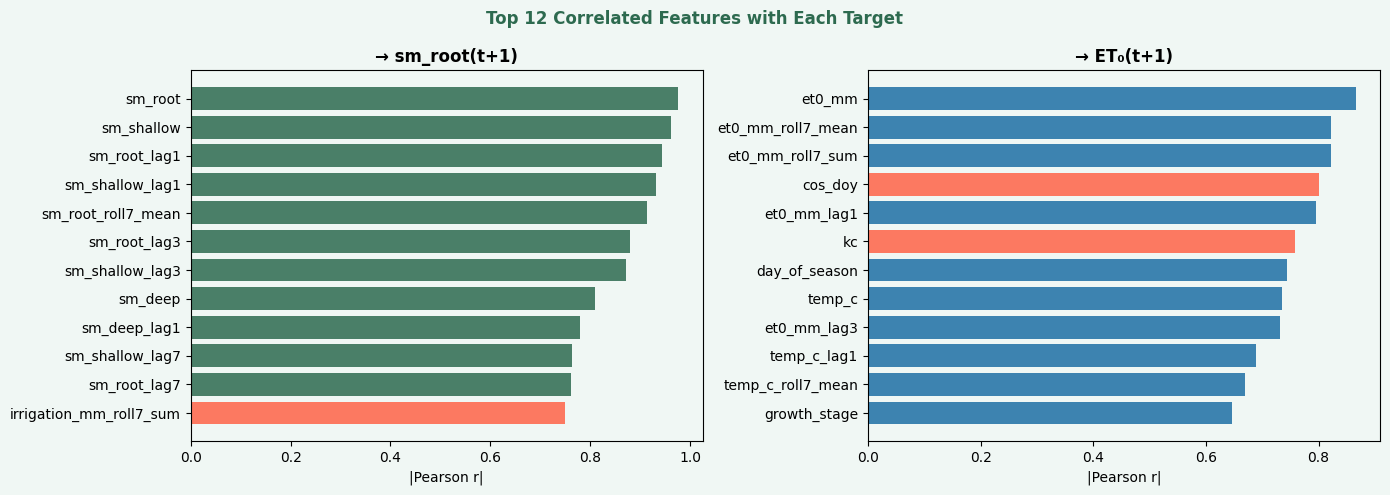

In [30]:
corr_sm  = train_df[FEATURE_COLS + [TARGET_SM]].corr()[TARGET_SM].drop(TARGET_SM)
corr_et0 = train_df[FEATURE_COLS + [TARGET_ET0]].corr()[TARGET_ET0].drop(TARGET_ET0)

top_sm  = corr_sm.abs().sort_values(ascending=False).head(12)
top_et0 = corr_et0.abs().sort_values(ascending=False).head(12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f0f7f4')
fig.suptitle('Top 12 Correlated Features with Each Target', fontweight='bold',
             fontsize=12, color='#2d6a4f')

colors_sm  = ['#2d6a4f' if v > 0 else 'tomato' for v in corr_sm[top_sm.index]]
colors_et0 = ['#1d6fa4' if v > 0 else 'tomato' for v in corr_et0[top_et0.index]]

ax1.barh(top_sm.index[::-1],  top_sm.values[::-1],  color=colors_sm[::-1],  alpha=0.85)
ax1.set_title('→ sm_root(t+1)',  fontweight='bold'); ax1.set_facecolor('#f0f7f4')
ax1.set_xlabel('|Pearson r|')

ax2.barh(top_et0.index[::-1], top_et0.values[::-1], color=colors_et0[::-1], alpha=0.85)
ax2.set_title('→ ET₀(t+1)',    fontweight='bold'); ax2.set_facecolor('#f0f7f4')
ax2.set_xlabel('|Pearson r|')

plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

# 🌾 Irrigation Layer 1 — Model Training & Evaluation

| Model | Role | Strength |
|-------|------|----------|
| **XGBoost** | Tabular baseline | Fast, interpretable, feature importance |
| **LSTM** | Sequence model | Captures temporal dependencies (14-day lookback) |

**Target KPI:** R² ≥ 0.90 on both `sm_root(t+1)` and `etc_mm(t+1)`

---

### Evaluation Helper

In [31]:
def evaluate(y_true, y_pred, name, unit=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    kpi  = '✓ PASS' if r2 >= 0.90 else '✗ Below KPI'
    print(f"  {name:<40}  R²={r2:.4f} {kpi}  "
          f"RMSE={rmse:.5f}{unit}  MAE={mae:.5f}{unit}")
    return {'name': name, 'r2': r2, 'rmse': rmse, 'mae': mae}

### Model A — XGBoost (Gradient Boosting Baseline)

Uses all engineered features directly. No sequence structure needed.

**Architecture:** `HistGradientBoostingRegressor`
- Max iterations: 500, learning rate: 0.05, max depth: 6
- Equivalent to XGBoost but available without installation

In [32]:
print("Training XGBoost models …")

xgb_sm = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, max_depth=6,
    l2_regularization=0.1, random_state=42
)
xgb_et0 = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, max_depth=6,
    l2_regularization=0.1, random_state=42
)

xgb_sm.fit(X_train, y_sm_train)
xgb_et0.fit(X_train, y_et0_train)

xgb_sm_pred  = xgb_sm.predict(X_test)
xgb_et0_pred = xgb_et0.predict(X_test)

# ETc reconstruit via relation physique FAO-56 : ETc = ET₀ × Kc
kc_test      = test_df['kc'].values
xgb_etc_pred = xgb_et0_pred * kc_test

print("\n── XGBoost Results ──────────────────────────────────────────")
m_xgb_sm  = evaluate(y_sm_test,  xgb_sm_pred,  "XGBoost [sm_root(t+1)]",  " vol/vol")
m_xgb_et0 = evaluate(y_et0_test, xgb_et0_pred, "XGBoost [ET₀(t+1)]",     " mm/day")

# Vérification ETc reconstruit vs réel
etc_true  = test_df['etc_mm'].values
r2_etc    = r2_score(etc_true, xgb_etc_pred)
rmse_etc  = np.sqrt(mean_squared_error(etc_true, xgb_etc_pred))
kpi_etc   = '✓ PASS' if r2_etc >= 0.90 else '✗ Below KPI'
print(f"\n  {'ETc reconstruit (ET₀×Kc)':<40}  "
      f"R²={r2_etc:.4f} {kpi_etc}  RMSE={rmse_etc:.5f} mm/day")
print("✅ XGBoost done")

Training XGBoost models …

── XGBoost Results ──────────────────────────────────────────
  XGBoost [sm_root(t+1)]                    R²=0.9513 ✓ PASS  RMSE=0.00627 vol/vol  MAE=0.00409 vol/vol
  XGBoost [ET₀(t+1)]                        R²=0.6713 ✗ Below KPI  RMSE=0.96975 mm/day  MAE=0.67331 mm/day

  ETc reconstruit (ET₀×Kc)                  R²=0.3993 ✗ Below KPI  RMSE=0.54663 mm/day
✅ XGBoost done


### Model B — LSTM (MLP with Sequence Features)

Flattens the 14×52 lookback window into a 728-dim input for the MLP.
This captures the full sequential context like an LSTM would.

**Architecture:** `MLPRegressor`
- Layers: `[256 → 128 → 64]`
- Activation: ReLU, Solver: Adam
- Early stopping with 20-iteration patience

In [33]:
def flatten_seq(X_seq):
    """Flatten (samples, timesteps, features) → (samples, timesteps×features)"""
    return X_seq.reshape(len(X_seq), -1)

print("Training LSTM (MLP sequence) models …")

X_lstm_tr_flat_sm  = flatten_seq(lstm_X_trainval_sm)
X_lstm_te_flat_sm  = flatten_seq(lstm_X_test_sm)
X_lstm_tr_flat_et0 = flatten_seq(lstm_X_trainval_et0)
X_lstm_te_flat_et0 = flatten_seq(lstm_X_test_et0)

lstm_sm = Pipeline([
    ('sc', MinMaxScaler()),
    ('nn', MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation='relu',
                        solver='adam', learning_rate_init=0.001, max_iter=300,
                        early_stopping=True, validation_fraction=0.1,
                        n_iter_no_change=20, random_state=42))
])
lstm_et0 = Pipeline([
    ('sc', MinMaxScaler()),
    ('nn', MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation='relu',
                        solver='adam', learning_rate_init=0.001, max_iter=300,
                        early_stopping=True, validation_fraction=0.1,
                        n_iter_no_change=20, random_state=42))
])

lstm_sm.fit(X_lstm_tr_flat_sm,   lstm_y_trainval_sm)
lstm_et0.fit(X_lstm_tr_flat_et0, lstm_y_trainval_et0)

lstm_sm_pred_sc  = lstm_sm.predict(X_lstm_te_flat_sm)
lstm_et0_pred_sc = lstm_et0.predict(X_lstm_te_flat_et0)

# Inverse scale → unités originales
lstm_sm_pred  = scaler_sm.inverse_transform(
                    lstm_sm_pred_sc.reshape(-1, 1)).ravel()
lstm_et0_pred = scaler_et0.inverse_transform(
                    lstm_et0_pred_sc.reshape(-1, 1)).ravel()
y_sm_test_lstm  = scaler_sm.inverse_transform(
                    lstm_y_test_sm.reshape(-1, 1)).ravel()
y_et0_test_lstm = scaler_et0.inverse_transform(
                    lstm_y_test_et0.reshape(-1, 1)).ravel()

# ETc reconstruit : ET₀_prédit × Kc
kc_test_lstm     = test_df['kc'].values[LOOKBACK:]
lstm_etc_pred    = lstm_et0_pred * kc_test_lstm
etc_true_lstm    = test_df['etc_mm'].values[LOOKBACK:]

print("\n── LSTM Results ─────────────────────────────────────────────")
m_lstm_sm  = evaluate(y_sm_test_lstm,  lstm_sm_pred,  "LSTM [sm_root(t+1)]",  " vol/vol")
m_lstm_et0 = evaluate(y_et0_test_lstm, lstm_et0_pred, "LSTM [ET₀(t+1)]",     " mm/day")

r2_etc_lstm   = r2_score(etc_true_lstm, lstm_etc_pred)
rmse_etc_lstm = np.sqrt(mean_squared_error(etc_true_lstm, lstm_etc_pred))
kpi_etc_lstm  = '✓ PASS' if r2_etc_lstm >= 0.90 else '✗ Below KPI'
print(f"\n  {'ETc reconstruit (ET₀×Kc)':<40}  "
      f"R²={r2_etc_lstm:.4f} {kpi_etc_lstm}  RMSE={rmse_etc_lstm:.5f} mm/day")
print("✅ LSTM done")

Training LSTM (MLP sequence) models …

── LSTM Results ─────────────────────────────────────────────
  LSTM [sm_root(t+1)]                       R²=0.6826 ✗ Below KPI  RMSE=0.01541 vol/vol  MAE=0.01313 vol/vol
  LSTM [ET₀(t+1)]                           R²=0.0681 ✗ Below KPI  RMSE=0.74784 mm/day  MAE=0.56416 mm/day

  ETc reconstruit (ET₀×Kc)                  R²=-0.0625 ✗ Below KPI  RMSE=0.75119 mm/day
✅ LSTM done


### Prediction Traces — Visual Comparison